# This example appliess a **logistic regression model** for binary classification, on the *iris* dataset.

Since this dataset considers three different classes

*   0.0 for iris setosa
*   1.0 for iris versicolor
*   2.0 for iris virginica

We firstly must reformulate the problem as a **binary classification task**: we will focus the task on classifying new instances as *iris virginica* (positive class: 1) or *not iris virginica* (negative class: 0).

In [126]:
import numpy as np
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
iris = datasets.load_iris()
X = iris["data"][:,:]
y = (iris["target"] == 2).astype(int)

#OPTIONAL CODE: Convert the iris dataset inton a Pandas DataFrame structure to view it nicely
dfiris = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])
dfiris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [127]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [128]:
# @title LogReg from scratch (MSE)
class LogisticRegressionScratchMSE:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.w = None
        self.b = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        probs = self.sigmoid(z)

        # Return the class with the highest probability
        return np.where(probs >= 0.5, 1, 0)

    def initialize_weights(self, n_features):
        self.w = np.zeros((n_features, 1))  # Init with the same column number as feature
        self.b = 0

    def cost_function(self, h, y):
        m = len(y)
        # reg_term = (0.01 / (2 * m)) * np.sum(self.w ** 2)
        cost = (1/m) * np.sum((h - y)**2)

        return cost #+ reg_term

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)  # Ensure y is a column vector
        print(X.shape, y.shape)
        m = len(y)
        n_features = X.shape[1]
        self.initialize_weights(n_features)

        for i in range(self.num_iterations):
            # Forward prop
            probs = self.predict(X)

            # Cost
            # error = -(1 / m) * np.sum(y * np.log(probs + 1e-8) + (1 - y) * np.log(1 - probs + 1e-8))
            error = self.cost_function(probs, y)
            self.losses.append(error)

            # Calculate the gradient of the error with respect to the weights
            gradient_w = (1 / m) * np.dot(X.T, (probs - y))
            gradient_b = (1 / m) * np.sum(probs - y)

            # Update the weights using the gradient and the learning rate
            self.w -= self.learning_rate * gradient_w
            self.b -= self.learning_rate * gradient_b

            # cost compute if more iteration (optional)
            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {error}")

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(range(self.num_iterations), self.losses, label='MSE Loss')
        plt.xlabel("Iteration")
        plt.ylabel("Loss (MSE)")
        plt.title("Loss Curve: Logistic Regression (MSE)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


(150, 4) (150, 1)
Iteration 0, Cost: 0.6666666666666667
Iteration 100, Cost: 0.2066666666666667
Iteration 200, Cost: 0.03333333333333333
Iteration 300, Cost: 0.013333333333333334
Iteration 400, Cost: 0.013333333333333334
Iteration 500, Cost: 0.03333333333333333
Iteration 600, Cost: 0.02
Iteration 700, Cost: 0.02
Iteration 800, Cost: 0.013333333333333334
Iteration 900, Cost: 0.013333333333333334


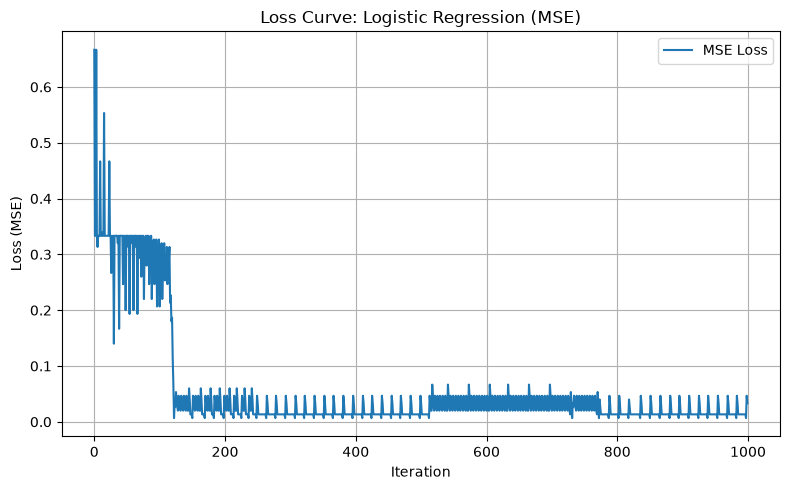

In [129]:
# Train Logistic Regression from scratch
MSEmodel_scratch = LogisticRegressionScratchMSE(learning_rate=1e-2, num_iterations=1000)
MSEmodel_scratch.fit(X, y)

# Predict and evaluate
MSEpred_scratch = MSEmodel_scratch.predict(X)
MSEmodel_scratch.plot_loss()

In [130]:
# Import necessary libraries
from sklearn.metrics import accuracy_score
score = accuracy_score(y, MSEpred_scratch)
score

0.9866666666666667

In [131]:
X_sampling = ([[7.7, 3.1, 6.4, 1.8],
      [5.8, 2.4, 4.6, 1.4]])
sampling_pred_scratch = MSEmodel_scratch.predict(X_sampling)
sampling_pred_scratch

array([[1],
       [0]])

In [132]:
# @title LogReg from scratch (BCE)
class LogisticRegressionScratchBCE:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.w = None
        self.b = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        probs = self.sigmoid(z)

        # Return the class with the highest probability
        return np.where(probs >= 0.5, 1, 0)

    def initialize_weights(self, n_features):
        self.w = np.zeros((n_features, 1))  # Init with the same column number as feature
        self.b = 0

    def cost_function(self, h, y):
        m = len(y)
        # reg_term = (0.01 / (2 * m)) * np.sum(self.w ** 2)
        cost = -(1 / m) * np.sum(y * np.log(h + 1e-8) + (1 - y) * np.log(1 - h + 1e-8))

        return cost #+ reg_term

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)  # Ensure y is a column vector
        print(X.shape, y.shape)
        m = len(y)
        n_features = X.shape[1]
        self.initialize_weights(n_features)

        for i in range(self.num_iterations):
            # Forward prop
            probs = self.predict(X)

            # Cost
            # error = -(1 / m) * np.sum(y * np.log(probs + 1e-8) + (1 - y) * np.log(1 - probs + 1e-8))
            error = self.cost_function(probs, y)
            self.losses.append(error)

            # Calculate the gradient of the error with respect to the weights
            gradient_w = (1 / m) * np.dot(X.T, (probs - y))
            gradient_b = (1 / m) * np.sum(probs - y)

            # Update the weights using the gradient and the learning rate
            self.w -= self.learning_rate * gradient_w
            self.b -= self.learning_rate * gradient_b

            # cost compute if more iteration (optional)
            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {error}")

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(range(self.num_iterations), self.losses, label='MSE Loss')
        plt.xlabel("Iteration")
        plt.ylabel("Loss (MSE)")
        plt.title("Loss Curve: Logistic Regression (BCE)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


(150, 4) (150, 1)
Iteration 0, Cost: 12.280453825968246
Iteration 100, Cost: 3.8069406791501565
Iteration 200, Cost: 0.6140226817984122
Iteration 300, Cost: 0.24560906671936494
Iteration 400, Cost: 0.24560906671936494
Iteration 500, Cost: 0.6140226817984122
Iteration 600, Cost: 0.3684136050790473
Iteration 700, Cost: 0.3684136050790473
Iteration 800, Cost: 0.24560906671936494
Iteration 900, Cost: 0.24560906671936494


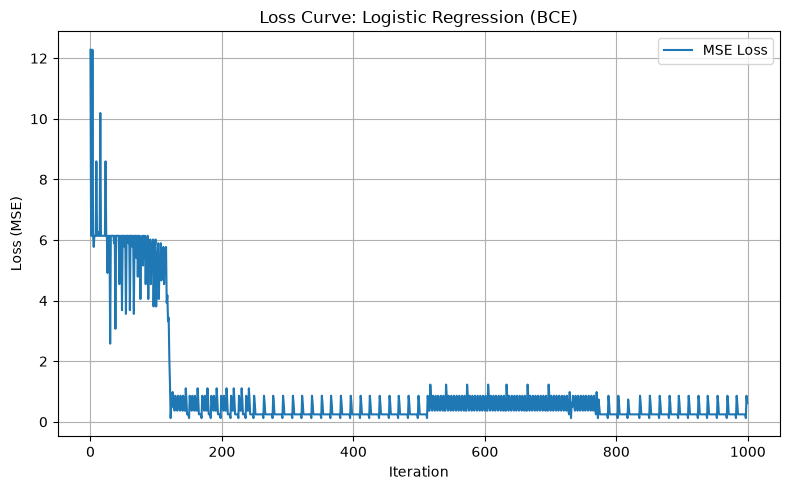

In [133]:
# Train Logistic Regression from scratch
BCEmodel_scratch = LogisticRegressionScratchBCE(learning_rate=1e-3, num_iterations=1000)
BCEmodel_scratch.fit(X, y)

# Predict and evaluate
BCE_pred_scratch = BCEmodel_scratch.predict(X)
BCEmodel_scratch.plot_loss()

In [134]:
# Import necessary libraries
from sklearn.metrics import accuracy_score
score = accuracy_score(y, BCE_pred_scratch)
score

0.9866666666666667

In [135]:
X_sampling = ([[7.7, 3.1, 6.4, 1.8],
      [5.8, 2.4, 4.6, 1.4]])
sampling_pred_scratch = BCEmodel_scratch.predict(X_sampling)
sampling_pred_scratch

array([[1],
       [0]])

In [136]:
# @title LogReg from Scikit-learn API
from sklearn.linear_model import LogisticRegression

X_sc = iris["data"][:,:]
y = (iris["target"] == 2).astype(np.int32)
log_reg = LogisticRegression()
log_reg.fit(X_sc, y)

X_sampling = [[7.7, 3.1, 6.4, 1.8],
              [5.8, 2.4, 4.6, 1.4]]
log_reg.predict(X_sampling)

array([1, 0], dtype=int32)

In [137]:
log_reg.score(X_sc, y)

0.9733333333333334

In [138]:
# Use the trained logistic regression model (log_reg) to predict the probability of each class
# The .predict_proba(X_sampling) method returns an array with 2 columns:
#    - Column 0: Probability that the sample belongs to class 0
#    - Column 1: Probability that the sample belongs to class 1
y_probab = log_reg.predict_proba(X_sampling)
y_probab

array([[0.01711564, 0.98288436],
       [0.74740984, 0.25259016]])

In this second example, we use only one of the four predictor attributes, *petal width*, to predict whether a flower observation with a given petal width would be **iris virgínica** or not.

In [139]:
X = iris["data"][:, 3:] # For next predictions, consider only one attribute: petal width
y = (iris["target"] == 2).astype(np.int32)
X[:10] # Petal width

array([[0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.4],
       [0.3],
       [0.2],
       [0.2],
       [0.1]])

If considering on only *petal width* affect to the type of iris flower dataset

In [140]:
log_reg = LogisticRegression()
log_reg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

We will see that the more petal width is Iris Virginica flower, the less petal wdith is flower out of Iris Virginica class.

In [141]:
X_new = np.linspace(0, 3, 500).reshape(-1, 1)
y_probab = log_reg.predict_proba(X_new)
y_probab[:10]

array([[9.99249051e-01, 7.50949397e-04],
       [9.99229249e-01, 7.70751232e-04],
       [9.99208925e-01, 7.91074809e-04],
       [9.99188066e-01, 8.11933853e-04],
       [9.99166658e-01, 8.33342450e-04],
       [9.99144685e-01, 8.55315053e-04],
       [9.99122134e-01, 8.77866494e-04],
       [9.99098988e-01, 9.01011997e-04],
       [9.99075233e-01, 9.24767180e-04],
       [9.99050852e-01, 9.49148074e-04]])

(np.float64(0.0), np.float64(3.0), np.float64(-0.02), np.float64(1.02))

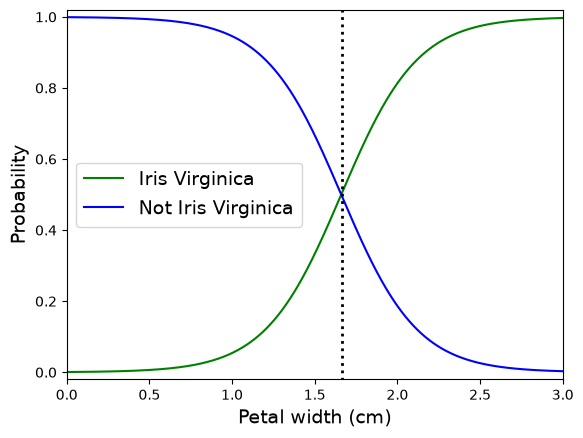

In [142]:
import matplotlib.pyplot as plt

# Show in a plot the probability of iris virginica as a function of the petal width (green solid line),
# The probability of not being iris virginica (blue dashed line), and the threshold value used by the model to separate both classes.
plt.plot(X_new, y_probab[:, 1], "g-", label="Iris Virginica")
plt.plot(X_new, y_probab[:, 0], "b-", label= "Not Iris Virginica")
decision_boundary = X_new[y_probab[:, 1] >= 0.5][0]
plt.plot([decision_boundary, decision_boundary], [-1, 2], "k:", linewidth=2)
plt.xlabel("Petal width (cm)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 3, -0.02, 1.02])

So, if we sample the *petal width* at upper (1.75 cm) and lower (1.55 cm) than boundary line at around ~1.6 cm, we are going to get Iris Virginica (class=1) and not Iris Virginica flowers (class=0), respectively.

In [143]:
log_reg.predict([[1.75], [1.55]])

array([1, 0], dtype=int32)

Third and last example, where we go back to the **original dataset** but this time we partition it into training and test to evaluate the logistic regression we will build upon training data.

In [144]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.25, random_state=0)

log_reg = LogisticRegression(max_iter=1000) # Use this hyperparameter to ensure convergence and avoid computing resource problems.
log_reg.fit(X_train, y_train)

test_predictions = log_reg.predict(X_test)

score = log_reg.score(X_test, y_test) # Calculate the model's predictive power on the test set as the % of correct predictions.
score

0.9736842105263158

# Homework

1. จงสร้างโมเดล Logistic Regression ที่รับค่า Input เป็นฟีเจอร์ดังต่อไปนี้ ['pH', 'density', 'alcohol'] โดยให้นำ Input ไป Scale ผ่าน Standardization ก่อน\
1.1 กำหนด Output เป็นเกณฑ์ในการจำแนกด้วยคุณภาพของไวน์ 'quality' ของ ข้อมูลมากกว่าหรือเท่ากับ 6.0 หรือไม่ \
1.2 แสดงค่า loss ที่ได้ทั้ง MSE และ BCE (ค่า loss ในแต่ละ iteration) ในรูปแบบของกราฟพล็อต \
1.3 เเสดงผลค่า Accuracy ที่ได้จากการใช้ loss ทั้ง 2 รูปแบบ พร้อมทั้งระบุว่าในโจทย์นี้เราควรใช้ loss รูปแบบใดและเพราะอะไร\
1.4 ประเมินผลด้วยการแสดงผล confusion matrix เปรียบเทียบการเรียนรู้ทั้ง 2 แบบด้วยผลลัพธ์นี้
---
1. Create a Logistic Regression model function that takes the following features as input: ['pH', 'density', 'alcohol']. Scale the input using a Standard Scaler \
1.1 Set the output as a criterion for determining whether the data's 'quality' is greater or equal than 6.0. \
1.2 Display the loss values ​​(MSE and BCE) for each iteration in a graph, and show the accuracy obtained using both loss methods. \
1.3 Specify which loss method is appropriate for this problem and why?\
1.4 Evaluate the results by displaying a confusion matrix. Compare the two learning methods using this result.

In [145]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [146]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("piyushgoyal443/red-wine-dataset")
folder_path = path
print(os.listdir(folder_path)) # เลือก "['wineQualityReds.csv']"

csv_path = os.path.join(folder_path, 'wineQualityReds.csv')
df = pd.read_csv(csv_path)

df.head()

['wineQualityReds.csv', 'wineQualityInfo.txt']


,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 1. จงสร้างโมเดล Logistic Regression ที่รับค่า Input เป็นฟีเจอร์ดังต่อไปนี้ ['pH', 'density', 'alcohol'] โดยให้นำ Input ไป Scale ผ่าน Standardization ก่อน

In [147]:
# แก้ fit ให้เหมากับ data ของโจทย์ที่ให้แปลงเป็น binary ก่อนแล้ว

class LogisticRegressionScratchMSE:
	def __init__(self, learning_rate=0.01, num_iterations=1000):
		self.learning_rate = learning_rate
		self.num_iterations = num_iterations
		self.w = None
		self.b = None
		self.losses = []

	def sigmoid(self, z):
		return 1 / (1 + np.exp(-z))

	def predict(self, X):
		z = np.dot(X, self.w) + self.b
		probs = self.sigmoid(z)

		return probs >= 0.5

	def initialize_weights(self, n_features):
		self.w = np.zeros((n_features, 1)) # Init with the same column number as feature
		self.b = 0

	def cost_function(self, y_hat, y_real):
		m = len(y_real)
		cost = (1/m) * np.sum((y_hat - y_real) ** 2)
		return cost 

	def fit(self, X, y):
		X = np.array(X)

		y = np.array(y, dtype=float).reshape(-1, 1)  
		print(X.shape, y.shape)
		m = len(y)
		n_features = X.shape[1]
		self.initialize_weights(n_features)

		for i in range(self.num_iterations):
			# 1. Calculate raw probabilities
			z = np.dot(X, self.w) + self.b
			probs = self.sigmoid(z)

			# 2. Cost
			error = self.cost_function(probs, y)
			self.losses.append(error)

			# 3. Calculate gradients (ใช้สมการ Gradient ของ MSE ที่รวมอนุพันธ์ของ Sigmoid)
			sigmoid_derivative = probs * (1 - probs)
			error_term = (probs - y) * sigmoid_derivative

			gradient_w = (1 / m) * np.dot(X.T, error_term)
			gradient_b = (1 / m) * np.sum(error_term)

			# 4. Update weights
			self.w -= self.learning_rate * gradient_w
			self.b -= self.learning_rate * gradient_b

			# cost compute if more iteration (optional)
			if i % 100 == 0:
				print(f"Iteration {i}, Cost: {error}")

	def plot_loss(self):
		plt.figure(figsize=(8, 5))
		plt.plot(range(self.num_iterations), self.losses, label='MSE Loss')
		plt.xlabel("Iteration")
		plt.ylabel("Loss (MSE)")
		plt.title("Loss Curve: Logistic Regression (MSE)")
		plt.grid(True)
		plt.legend()
		plt.tight_layout()
		plt.show()

In [ ]:
# แก้ fit ให้เหมากับ data ของโจทย์ที่ให้แปลงเป็น binary ก่อนแล้ว

class LogisticRegressionScratchBCE:
	def __init__(self, learning_rate=0.01, num_iterations=1000):
		self.learning_rate = learning_rate
		self.num_iterations = num_iterations
		self.w = None
		self.b = None
		self.losses = []

	def sigmoid(self, z):
		return 1 / (1 + np.exp(-z))

	def predict(self, X):
		z = np.dot(X, self.w) + self.b
		probs = self.sigmoid(z)

		return probs >= 0.5

	def initialize_weights(self, n_features):
		self.w = np.zeros((n_features, 1))  # Init with the same column number as feature
		self.b = 0

	def cost_function(self, y_hat, y_real):
		m = len(y_real)
		# reg_term = (0.01 / (2 * m)) * np.sum(self.w ** 2)
		cost = -(1 / m) * np.sum(y_real * np.log(y_hat + 1e-8) + (1 - y_real) * np.log(1 - y_hat + 1e-8))

		return cost #+ reg_term

	def fit(self, X, y):
		X = np.array(X)

		y = np.array(y, dtype=float).reshape(-1, 1)  
		print(X.shape, y.shape)
		m = len(y)
		n_features = X.shape[1]
		self.initialize_weights(n_features)

		for i in range(self.num_iterations):
			# 1. Forward prop
			z = np.dot(X, self.w) + self.b
			probs = self.sigmoid(z)

			# 2. Cost
			error = self.cost_function(probs, y)
			self.losses.append(error)

			# 3. Calculate the gradient 
			gradient_w = (1 / m) * np.dot(X.T, (probs - y))
			gradient_b = (1 / m) * np.sum(probs - y)

			# 4. Update the weights
			self.w -= self.learning_rate * gradient_w
			self.b -= self.learning_rate * gradient_b

			# cost compute if more iteration (optional)
			if i % 100 == 0:
				print(f"Iteration {i}, Cost: {error}")

	def plot_loss(self):
		plt.figure(figsize=(8, 5))
		plt.plot(range(self.num_iterations), self.losses, label='BCE Loss')
		plt.xlabel("Iteration")
		plt.ylabel("Loss (BCE)")
		plt.title("Loss Curve: Logistic Regression (BCE)")
		plt.grid(True)
		plt.legend()
		plt.tight_layout()
		plt.show()

In [149]:
df.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1599 non-null   int64  
 1   fixed.acidity         1599 non-null   float64
 2   volatile.acidity      1599 non-null   float64
 3   citric.acid           1599 non-null   float64
 4   residual.sugar        1599 non-null   float64
 5   chlorides             1599 non-null   float64
 6   free.sulfur.dioxide   1599 non-null   float64
 7   total.sulfur.dioxide  1599 non-null   float64
 8   density               1599 non-null   float64
 9   pH                    1599 non-null   float64
 10  sulphates             1599 non-null   float64
 11  alcohol               1599 non-null   float64
 12  quality               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


In [151]:
df.describe()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,800.000000,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,461.735855,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,1.000000,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,400.500000,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,800.000000,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,1199.500000,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,1599.000000,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [152]:
X = df[['pH', 'density', 'alcohol']]
X.head()

,pH,density,alcohol
0,3.51,0.9978,9.4
1,3.20,0.9968,9.8
2,3.26,0.9970,9.8
3,3.16,0.9980,9.8
4,3.51,0.9978,9.4


In [153]:
std_scaler = StandardScaler()
std_scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [154]:
X['pH'] = std_scaler.fit_transform(X[['pH']])
X['density'] = std_scaler.fit_transform(X[['density']])
X['alcohol'] = std_scaler.fit_transform(X[['alcohol']])
X.head()

,pH,density,alcohol
0,1.288643,0.558274,-0.960246
1,-0.719933,0.028261,-0.584777
2,-0.331177,0.134264,-0.584777
3,-0.979104,0.664277,-0.584777
4,1.288643,0.558274,-0.960246


#### 1.1 กำหนด Output เป็นเกณฑ์ในการจำแนกด้วยคุณภาพของไวน์ 'quality' ของ ข้อมูลมากกว่าหรือเท่ากับ 6.0 หรือไม่

In [155]:
y = df[['quality']]
y = y.map(lambda x: x >= 6.0, na_action='ignore')
y.head()

,quality
0,False
1,False
2,False
3,True
4,False


#### 1.2 แสดงค่า loss ที่ได้ทั้ง MSE และ BCE (ค่า loss ในแต่ละ iteration) ในรูปแบบของกราฟพล็อต

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mse_model = LogisticRegressionScratchMSE()
bce_model = LogisticRegressionScratchBCE()

In [157]:
mse_model.fit(X_train, y_train)

(1279, 3) (1279, 1)
Iteration 0, Cost: 0.25
Iteration 100, Cost: 0.24377989505150996
Iteration 200, Cost: 0.23850705168451225
Iteration 300, Cost: 0.23403849015445305
Iteration 400, Cost: 0.2302381488226256
Iteration 500, Cost: 0.2269872646935205
Iteration 600, Cost: 0.22418698275550059
Iteration 700, Cost: 0.2217570703423075
Iteration 800, Cost: 0.21963317341924252
Iteration 900, Cost: 0.21776385666769613


In [158]:
bce_model.fit(X_train, y_train)

(1279, 3) (1279, 1)
Iteration 0, Cost: 0.6931471605599454
Iteration 100, Cost: 0.6528957519020449
Iteration 200, Cost: 0.6299627560658323
Iteration 300, Cost: 0.6156843337917597
Iteration 400, Cost: 0.6061330886253891
Iteration 500, Cost: 0.599398807858948
Iteration 600, Cost: 0.594466918462803
Iteration 700, Cost: 0.5907534260380082
Iteration 800, Cost: 0.5878987158862474
Iteration 900, Cost: 0.5856689026417272


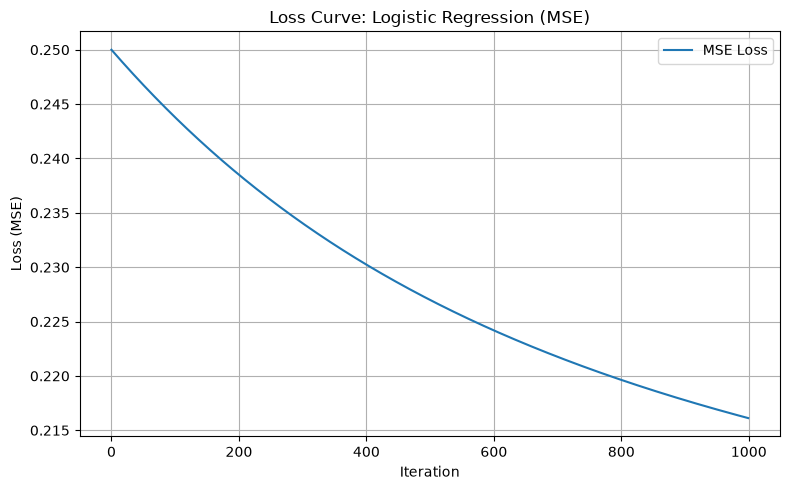

In [159]:
mse_model.plot_loss()

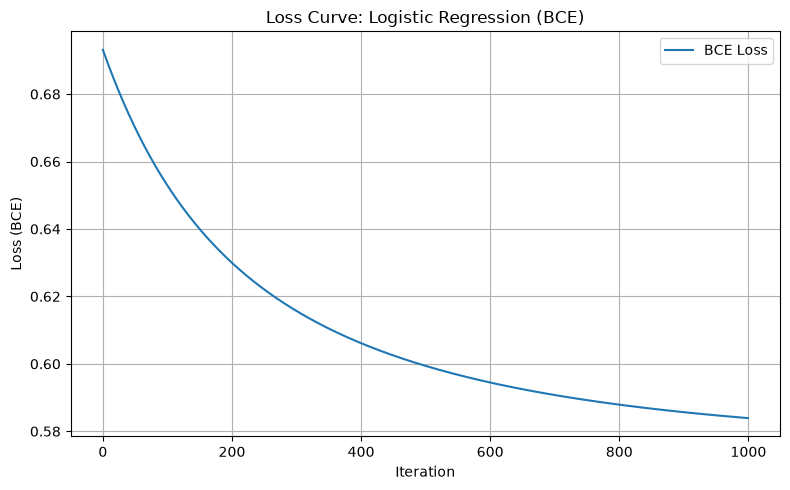

In [160]:
bce_model.plot_loss()

#### 1.3 เเสดงผลค่า Accuracy ที่ได้จากการใช้ loss ทั้ง 2 รูปแบบ พร้อมทั้งระบุว่าในโจทย์นี้เราควรใช้ loss รูปแบบใดและเพราะอะไร

In [161]:
y_pred_mse = mse_model.predict(X_test)
y_pred_bce = bce_model.predict(X_test)

acc_mse = accuracy_score(y_test, y_pred_mse)
acc_bce = accuracy_score(y_test, y_pred_bce)

print(f"Accuracy (MSE): {acc_mse:.4f}")
print(f"Accuracy (BCE): {acc_bce:.4f}")

Accuracy (MSE): 0.6937
Accuracy (BCE): 0.7219


- จากผลลัพธ์ของ Accuracy ของ BCE ดีกว่า MSE อย่างเห็นได้ชัดเพราะว่า data เป็นรูปแบบ binary loss BCE จึงเหมาะสมกว่า

#### 1.4 ประเมินผลด้วยการแสดงผล confusion matrix เปรียบเทียบการเรียนรู้ทั้ง 2 แบบด้วยผลลัพธ์นี้

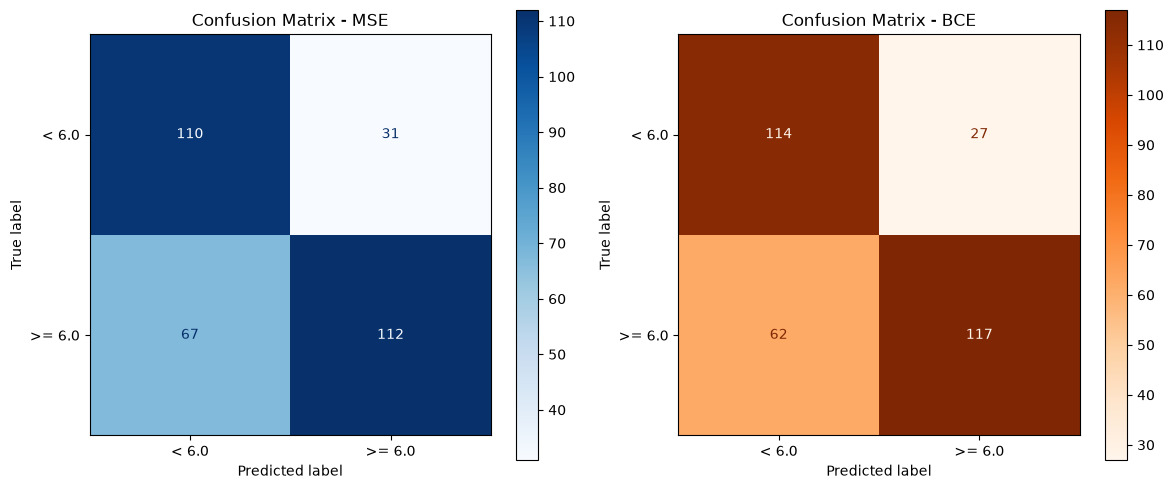

In [162]:
cm_mse = confusion_matrix(y_test, y_pred_mse)
cm_bce = confusion_matrix(y_test, y_pred_bce)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot MSE
disp_mse = ConfusionMatrixDisplay(confusion_matrix=cm_mse, display_labels=['< 6.0', '>= 6.0'])
disp_mse.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - MSE')

# Plot BCE
disp_bce = ConfusionMatrixDisplay(confusion_matrix=cm_bce, display_labels=['< 6.0', '>= 6.0'])
disp_bce.plot(ax=axes[1], cmap='Oranges')
axes[1].set_title('Confusion Matrix - BCE')

plt.tight_layout()
plt.show()